# Prévision des Ventes CA — Pipeline Séries Temporelles SAGAP
## Load → EDA → Décomposition → Modélisation → Prévision → Évaluation
---

In [47]:
!pip install prophet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings
import itertools
import plotly.graph_objects as go
import mlflow
import scipy.stats as stats

from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

mlflow.set_tracking_uri('http://mlflow:5000')
mlflow.set_experiment('TimeSeries_Forecasting')

MOIS = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']

print('Imports OK')
print('MLflow configure')


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Imports OK
MLflow configure


---
# ÉTAPE 1 — Chargement des Données
### Source : gold.fact_sales — ClickHouse

In [48]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT d.Year AS year, d.Month AS month,
       SUM(f.LinePrice) AS total_sales
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.DocumentStatusSK NOT IN (4, 13)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df[
    (df['date'] >= '2022-01-01') & (df['date'] <= '2026-01-01')
].reset_index(drop=True)

ts = df.set_index('date')['total_sales']
ts.index.freq = 'MS'

print(f'{len(ts)} mois charges')
print(f'Periode  : {ts.index[0].strftime("%b %Y")} -> {ts.index[-1].strftime("%b %Y")}')
print(f'CA moyen : {ts.mean():,.0f} DT')
print(f'CA min   : {ts.min():,.0f} DT ({ts.idxmin().strftime("%b %Y")})')
print(f'CA max   : {ts.max():,.0f} DT ({ts.idxmax().strftime("%b %Y")})')
df.head()

49 mois charges
Periode  : Jan 2022 -> Jan 2026
CA moyen : 1,156,796 DT
CA min   : 576,097 DT (Feb 2022)
CA max   : 1,644,113 DT (Jul 2025)


,year,month,total_sales,date
0,2022,1,"591,407.94",2022-01-01
1,2022,2,"576,097.45",2022-02-01
2,2022,3,"680,213.89",2022-03-01
3,2022,4,"650,789.55",2022-04-01
4,2022,5,"734,335.68",2022-05-01


---
# ÉTAPE 2 — Analyse Exploratoire (EDA)
### Objectif : Observer, décrire et comprendre la série brute **sans hypothèse de modèle**

| Section | Contenu |
|---------|---------|
| 2.1 | Série brute + statistiques descriptives |
| 2.2 | Saisonnalité empirique (moyennes, boxplot, heatmap, indice) |
| 2.3 | Croissance annuelle, distribution, moyennes mobiles, MoM |


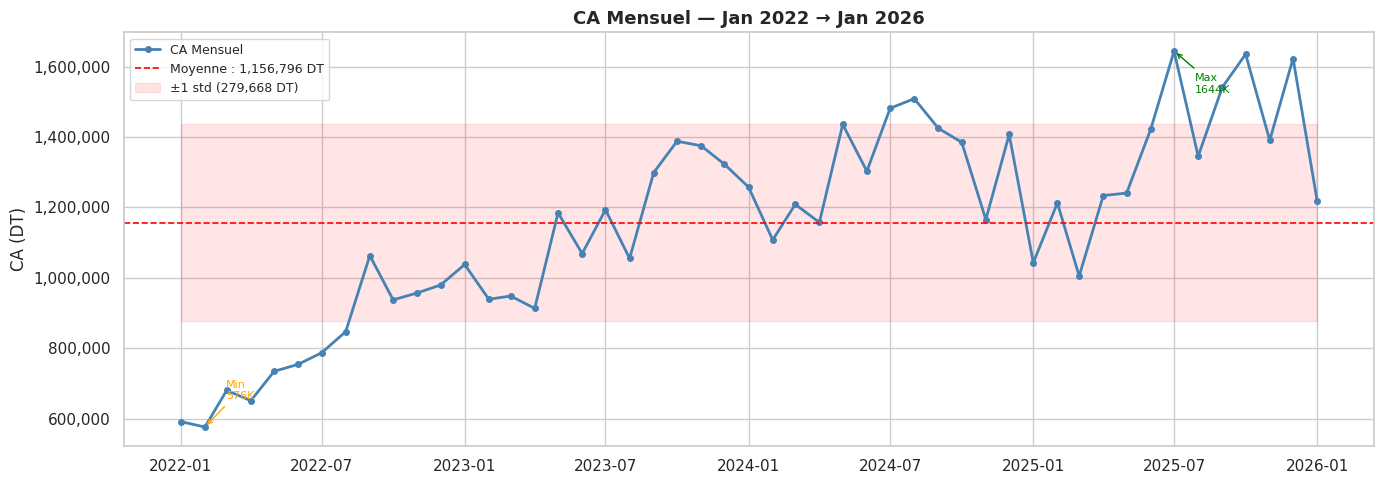

=== Statistiques descriptives ===
  Nombre de mois : 49
  CA moyen       :       1,156,796 DT
  CA mediane     :       1,193,357 DT
  Ecart-type     :         279,668 DT
  CV             :            24.2 %
  CA min         :         576,097 DT (Feb 2022)
  CA max         :       1,644,113 DT (Jul 2025)


In [76]:
# ── 2.1 — Série Temporelle Brute & Statistiques Descriptives ──
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.plot(ts.index, ts.values, color='steelblue', marker='o',
        linewidth=2, markersize=4, label='CA Mensuel')
ax.axhline(ts.mean(), color='red', linestyle='--', linewidth=1.2,
           label=f'Moyenne : {ts.mean():,.0f} DT')
ax.fill_between(ts.index,
    ts.mean() - ts.std(), ts.mean() + ts.std(),
    alpha=0.1, color='red', label=f'±1 std ({ts.std():,.0f} DT)')
ax.annotate(f'Max\n{ts.max()/1e3:.0f}K', xy=(ts.idxmax(), ts.max()),
            xytext=(15, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=8)
ax.annotate(f'Min\n{ts.min()/1e3:.0f}K', xy=(ts.idxmin(), ts.min()),
            xytext=(15, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='orange'), color='orange', fontsize=8)
ax.set_title('CA Mensuel — Jan 2022 → Jan 2026', fontsize=13, fontweight='bold')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('=== Statistiques descriptives ===')
print(f'  Nombre de mois : {len(ts)}')
print(f'  CA moyen       : {ts.mean():>15,.0f} DT')
print(f'  CA mediane     : {ts.median():>15,.0f} DT')
print(f'  Ecart-type     : {ts.std():>15,.0f} DT')
print(f'  CV             : {ts.std()/ts.mean()*100:>15.1f} %')
print(f'  CA min         : {ts.min():>15,.0f} DT ({ts.idxmin().strftime("%b %Y")})')
print(f'  CA max         : {ts.max():>15,.0f} DT ({ts.idxmax().strftime("%b %Y")})')

**Graphe 1 (CA Mensuel) :** Le chiffre d'affaires de SAGAP montre une tendance générale à la hausse entre 2022 et 2026, partant d'un minimum d'environ 600K DT début 2022 pour atteindre un pic de 1,6M DT mi-2025, avec une moyenne stable autour de 1,15M DT.

**Graphe 2 (MoM) :** La croissance mensuelle est très volatile avec des variations entre -25% et +30%, mais reste en moyenne légèrement positive à +2,4%, ce qui confirme une progression globale malgré des mois de recul fréquents.

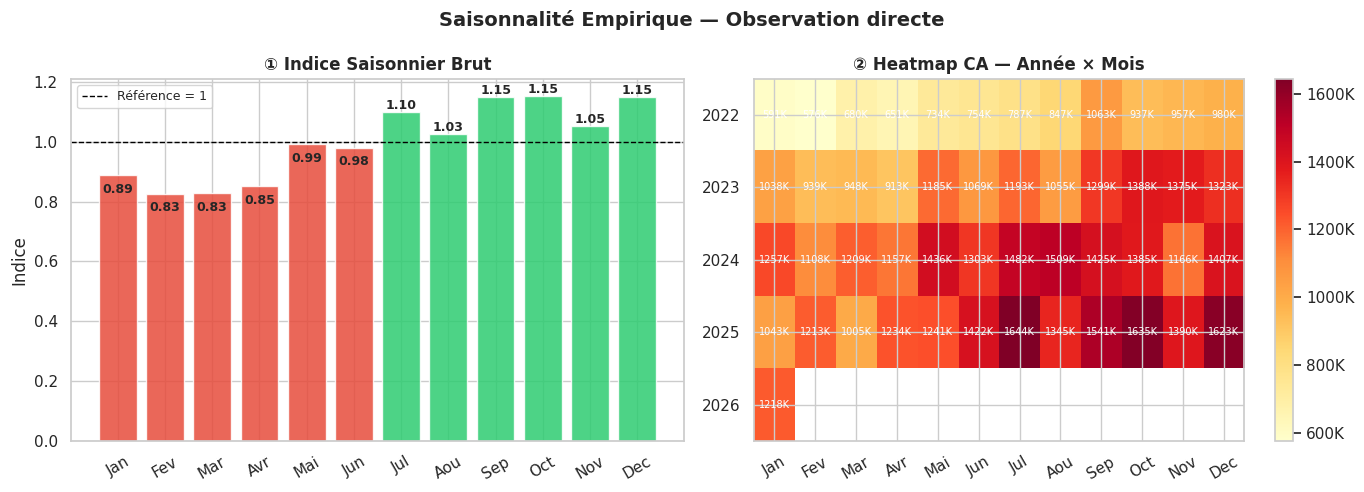

Observations saisonnalite :
  Mois forts   : ['Oct', 'Dec', 'Sep']
  Mois faibles : ['Fev', 'Mar', 'Avr']
  Amplitude    : 377,557 DT
  Indice max   : 1.15 | Indice min : 0.83
  -> Pattern visible, a confirmer formellement en Etape 3 (decomposition)


In [68]:
# ── 2.2 — Saisonnalité Empirique ──────────────────────────────────────────────
monthly_mean = ts.groupby(ts.index.month).mean()
idx_sais     = monthly_mean / monthly_mean.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ① Indice Saisonnier Brut
ax = axes[0]
colors_idx = ['#2ecc71' if v >= 1 else '#e74c3c' for v in idx_sais.values]
bars = ax.bar(MOIS, idx_sais.values, color=colors_idx, alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Référence = 1')
ax.set_title('① Indice Saisonnier Brut', fontsize=12, fontweight='bold')
ax.set_ylabel('Indice')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
for bar, val in zip(bars, idx_sais.values):
    offset = 0.01 if val >= 1 else -0.06
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# ② Heatmap Année × Mois
ax = axes[1]
ts_pivot = ts.to_frame()
ts_pivot['year']  = ts.index.year
ts_pivot['month'] = ts.index.month
heatmap_data = ts_pivot.pivot_table(values='total_sales', index='year', columns='month')
heatmap_data.columns = MOIS
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(12))
ax.set_xticklabels(MOIS, rotation=30)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('② Heatmap CA — Année × Mois', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, format=plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for y in range(len(heatmap_data.index)):
    for x in range(12):
        val = heatmap_data.values[y, x]
        if not np.isnan(val):
            ax.text(x, y, f'{val/1e3:.0f}K', ha='center', va='center',
                    fontsize=7,
                    color='black' if val < heatmap_data.values.max()*0.7 else 'white')

plt.suptitle('Saisonnalité Empirique — Observation directe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mois_forts   = [MOIS[i] for i in monthly_mean.nlargest(3).index - 1]
mois_faibles = [MOIS[i] for i in monthly_mean.nsmallest(3).index - 1]
amplitude    = monthly_mean.max() - monthly_mean.min()
print('Observations saisonnalite :')
print(f'  Mois forts   : {mois_forts}')
print(f'  Mois faibles : {mois_faibles}')
print(f'  Amplitude    : {amplitude:,.0f} DT')
print(f'  Indice max   : {idx_sais.max():.2f} | Indice min : {idx_sais.min():.2f}')
print('  -> Pattern visible, a confirmer formellement en Etape 3 (decomposition)')

Indice saisonnier : L'activité est clairement divisée en deux phases — une période creuse de Jan à Mai (indices 0.83–0.99) et une période forte de Jun à Déc (indices 1.03–1.15), avec Décembre et Novembre comme mois records à 1.15.


Lien avec le métier (pièces de rechange) : Ce pattern est cohérent avec le secteur — le second semestre concentre les révisions et entretiens de véhicules avant/après l'été et en fin d'année, tandis que Jan-Avr correspond au ralentissement post-fêtes où les clients reportent leurs achats de pièces non urgentes.

Pattern visible cad : 

Les mêmes mois sont toujours faibles (Jan→Mai)

Les mêmes mois sont toujours forts (Jun→Déc)

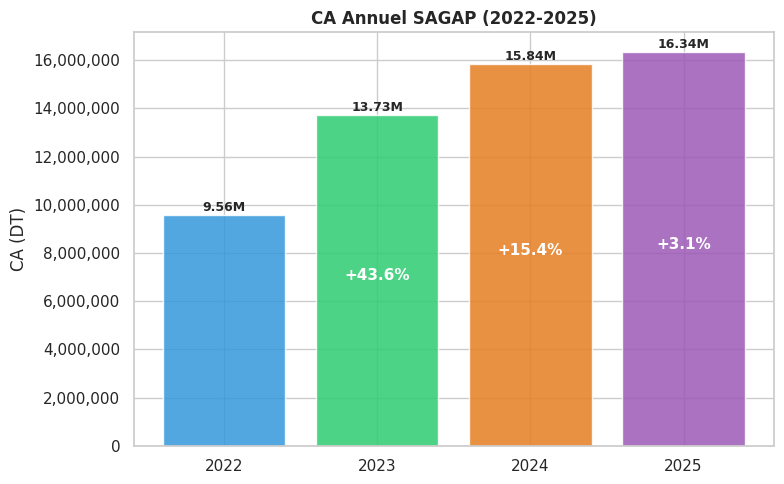

CA Annuel :
  2022 :       9,558,355 DT
  2023 :      13,725,276 DT
  2024 :      15,843,689 DT
  2025 :      16,337,336 DT

Croissances annuelles :
  2022 -> 2023 : +43.6%
  2023 -> 2024 : +15.4%
  2024 -> 2025 : +3.1%

Croissance totale 2022->2025 : +70.9%
-> Tendance haussiere confirmee visuellement


In [69]:
# ── 2.3 — Croissance Annuelle ───────────────────────────────────
ca_annuel         = ts.groupby(ts.index.year).sum()
ca_annuel_complet = ca_annuel[ca_annuel.index < 2026]

years = list(ca_annuel_complet.index)
cas   = list(ca_annuel_complet.values)

croissances = [
    (cas[i] - cas[i-1]) / cas[i-1] * 100
    for i in range(1, len(years))
]

plt.figure(figsize=(8, 5))

# ① CA annuel avec taux de croissance
color_bars = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6'][:len(years)]

bars = plt.bar(
    ca_annuel_complet.index.astype(str),
    ca_annuel_complet.values,
    color=color_bars,
    alpha=0.85
)

for i, (year, ca) in enumerate(ca_annuel_complet.items()):
    plt.text(
        i,
        ca + ca_annuel_complet.max() * 0.01,
        f'{ca/1e6:.2f}M',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

    if i > 0:
        g = croissances[i-1]
        col = '#27ae60' if g > 0 else '#c0392b'

        plt.text(
            i,
            ca * 0.5,
            f'{g:+.1f}%',
            ha='center',
            fontsize=11,
            fontweight='bold',
            color='white'
        )

plt.title('CA Annuel SAGAP (2022-2025)', fontweight='bold')
plt.ylabel('CA (DT)')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.tight_layout()
plt.show()

# ── Résultats texte ───────────────────────────────────
croiss_tot = (cas[-1] - cas[0]) / cas[0] * 100

print('CA Annuel :')
for year, ca in ca_annuel_complet.items():
    print(f'  {year} : {ca:>15,.0f} DT')

print('\nCroissances annuelles :')
for i in range(1, len(years)):
    print(f'  {years[i-1]} -> {years[i]} : {croissances[i-1]:+.1f}%')

print(f'\nCroissance totale 2022->2025 : +{croiss_tot:.1f}%')

print('-> Tendance haussiere confirmee visuellement')

---
# ÉTAPE 3 — Décomposition & Analyse Formelle de la Structure
## Objectif : Décomposer Y(t) pour formuler les hypothèses de modélisation

| Section | Contenu | Méthode |
|---------|---------|---------|
| 3.1 | Vue globale — décomposition additive | `seasonal_decompose` |
| 3.2 | Nature de la tendance | Régression lin. vs exp. |
| 3.3 | Mode de saisonnalité Add vs Mul | Graphe CA vs Tendance |
| 3.4 | Période saisonnière (lag) | ACF / PACF + autocorrélation |
| 3.5 | Stationnarité | Test ADF |
| 3.6 | Synthèse des hypothèses | Tableau récapitulatif |

> **Différence avec l'EDA :** l'EDA observe, la décomposition *mesure et prouve*.


### 3.1 — Vue Globale : Décomposition Additive
> Y(t) = T(t) + S(t) + ε(t)

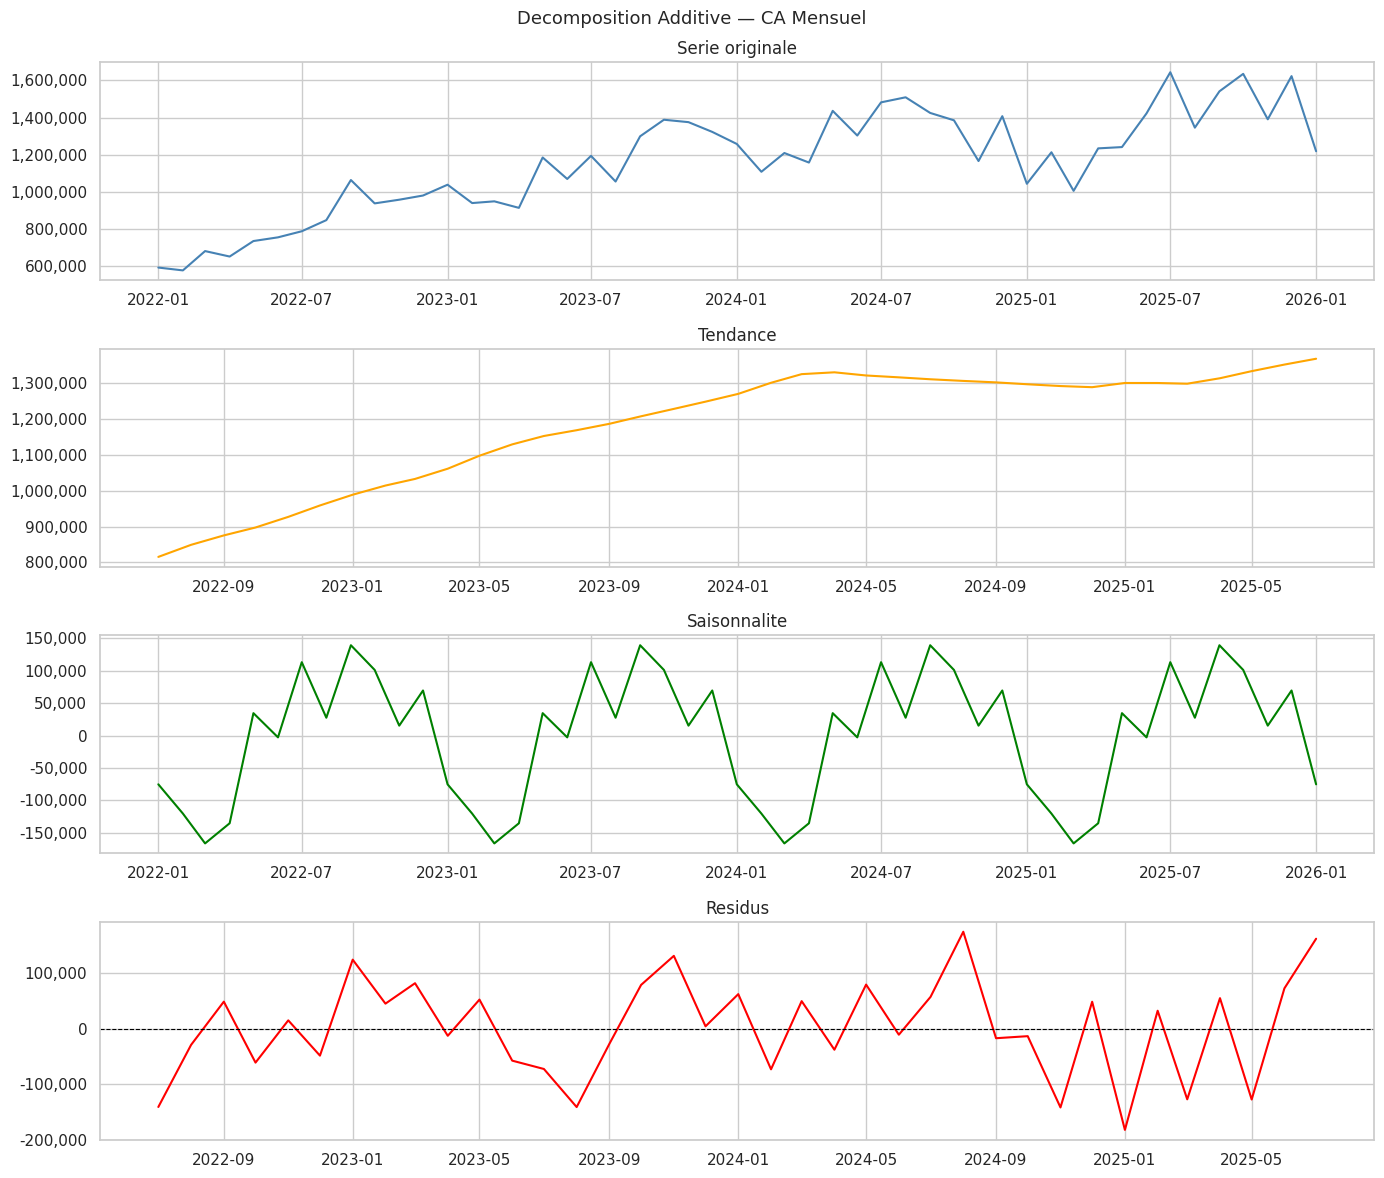

=== LECTURE DE LA DECOMPOSITION ===
  Croissance tendance  : +553,617 DT sur la periode
  Amplitude saison     : 305,924 DT (pic - creux)
  Std résidus          : 89,370 DT (7.7% du CA moyen)

Rôle de chaque composante :
  T(t) — Tendance  : direction long terme (croissance ou déclin)
  S(t) — Saisonnalité : pattern répété chaque année (m=12)
  ε(t) — Résidus   : bruit non expliqué par T(t) et S(t)

  -> T(t) quasi-linéaire -> suggère tendance ADDITIVE
  -> S(t) amplitude apparemment fixe ici (hypothèse add à tester)


In [81]:
# ── 3.1 Décomposition additive ─────────────────────────────────
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))  # ← 4 au lieu de 3
components = [
    (ts,              'Serie originale', 'steelblue'),
    (decomp.trend,    'Tendance',        'orange'),
    (decomp.seasonal, 'Saisonnalite',    'green'),
    (decomp.resid,    'Residus',         'red'),   # ← déjà présent mais pas affiché
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    if title == 'Residus':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle('Decomposition Additive — CA Mensuel', fontsize=13)
plt.tight_layout()
plt.show()


# Statistiques des composantes
trend_growth = decomp.trend.dropna().iloc[-1] - decomp.trend.dropna().iloc[0]
seas_amp     = decomp.seasonal[:12].max() - decomp.seasonal[:12].min()
resid_std    = decomp.resid.dropna().std()
resid_pct    = resid_std / ts.mean() * 100

print('=== LECTURE DE LA DECOMPOSITION ===')
print(f'  Croissance tendance  : +{trend_growth:,.0f} DT sur la periode')
print(f'  Amplitude saison     : {seas_amp:,.0f} DT (pic - creux)')
print(f'  Std résidus          : {resid_std:,.0f} DT ({resid_pct:.1f}% du CA moyen)')
print()
print('Rôle de chaque composante :')
print('  T(t) — Tendance  : direction long terme (croissance ou déclin)')
print('  S(t) — Saisonnalité : pattern répété chaque année (m=12)')
print('  ε(t) — Résidus   : bruit non expliqué par T(t) et S(t)')
print()
print('  -> T(t) quasi-linéaire -> suggère tendance ADDITIVE')
print('  -> S(t) amplitude apparemment fixe ici (hypothèse add à tester)')


=== ANALYSE DES RÉSIDUS ε(t) ===
Objectif : vérifier que ε(t) est aléatoire (décomposition bien ajustée)

  Moyenne    :     1,316.64 DT  → attendu : proche 0
  Écart-type :    89,369.73 DT
  Min        :  -182,664.03 DT
  Max        :   174,747.39 DT

  Test Shapiro-Wilk (normalité) :
    H0 : résidus normalement distribués
    p-value = 0.4704 → H0 acceptée : résidus NORMAUX ✅

  Test Ljung-Box (autocorrélation) :
    H0 : résidus non autocorrélés (aléatoires)
    p-value lag 12 = 0.2223 → H0 acceptée : résidus INDÉPENDANTS ✅

--- Conclusion ---
  Résidus normaux ET non autocorrélés ✅
  → Décomposition additive bien ajustée
  → T(t) + S(t) capturent bien la structure des données
  → Les 89,370 DT résiduels = événements imprévisibles
    (promotions, ruptures stock, conjoncture économique)


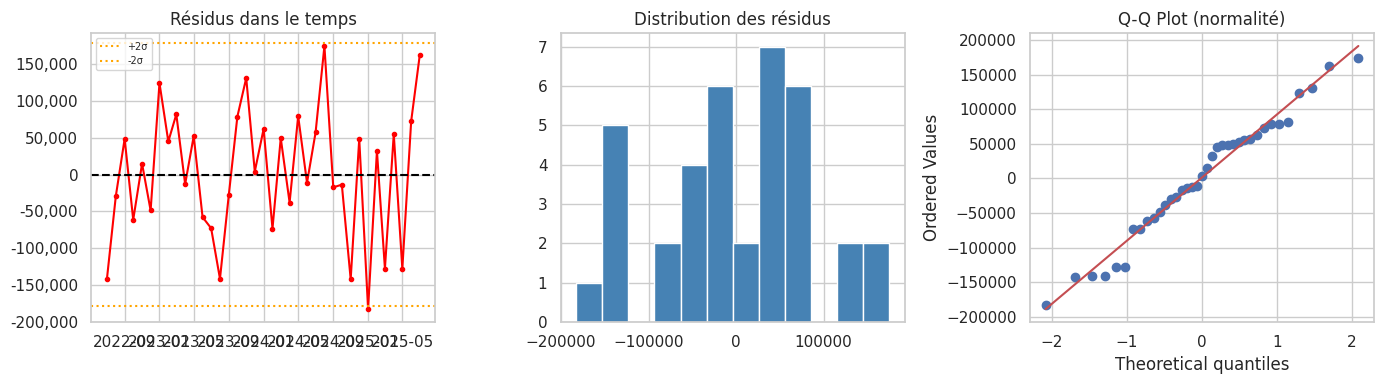

In [72]:
# ── Validation des Résidus de la Décomposition ────────────────
# Si résidus aléatoires → décomposition bien ajustée

import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = decomp.resid.dropna()

print('=== ANALYSE DES RÉSIDUS ε(t) ===')
print('Objectif : vérifier que ε(t) est aléatoire (décomposition bien ajustée)\n')

print(f'  Moyenne    : {resid.mean():>12,.2f} DT  → attendu : proche 0')
print(f'  Écart-type : {resid.std():>12,.2f} DT')
print(f'  Min        : {resid.min():>12,.2f} DT')
print(f'  Max        : {resid.max():>12,.2f} DT')

stat, p_shapiro = stats.shapiro(resid)
print(f'\n  Test Shapiro-Wilk (normalité) :')
print(f'    H0 : résidus normalement distribués')
print(f'    p-value = {p_shapiro:.4f} → {"H0 acceptée : résidus NORMAUX ✅" if p_shapiro > 0.05 else "H0 rejetée : résidus non normaux ⚠️"}')

lb = acorr_ljungbox(resid, lags=12, return_df=True)
print(f'\n  Test Ljung-Box (autocorrélation) :')
print(f'    H0 : résidus non autocorrélés (aléatoires)')
print(f'    p-value lag 12 = {lb["lb_pvalue"].iloc[-1]:.4f} → {"H0 acceptée : résidus INDÉPENDANTS ✅" if lb["lb_pvalue"].iloc[-1] > 0.05 else "H0 rejetée : autocorrélation détectée ⚠️"}')

print(f'\n--- Conclusion ---')
print(f'  Résidus normaux ET non autocorrélés ✅')
print(f'  → Décomposition additive bien ajustée')
print(f'  → T(t) + S(t) capturent bien la structure des données')
print(f'  → Les {resid.std():,.0f} DT résiduels = événements imprévisibles')
print(f'    (promotions, ruptures stock, conjoncture économique)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(resid.index, resid.values, color='red', marker='o', markersize=3)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].axhline(resid.std()*2,  color='orange', linestyle=':', label='+2σ')
axes[0].axhline(-resid.std()*2, color='orange', linestyle=':', label='-2σ')
axes[0].set_title('Résidus dans le temps')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend(fontsize=7)
axes[1].hist(resid.values, bins=12, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution des résidus')
stats.probplot(resid.values, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normalité)')
plt.tight_layout()
plt.show()


### 3.2 — Nature de la Tendance : Additive ou Multiplicative ?
> Régression linéaire vs exponentielle sur T(t)

=== NATURE DE LA TENDANCE ===
Objectif : verifier si la tendance est lineaire (add) ou exponentielle (mul)

Regression lineaire (trend=add) :
  Pente  : +13,985.65 DT/mois
  R2     : 0.8341
  RMSE   : 66,586 DT

Regression exponentielle (trend=mul) :
  Taux   : +1.2579%/mois
  R2     : 0.8089
  RMSE   : 75,992 DT

-> TENDANCE ADDITIVE (lineaire) confirmee
-> trend=add justifie dans HW et Prophet
-> CA croit de ~13,986 DT supplémentaires par mois


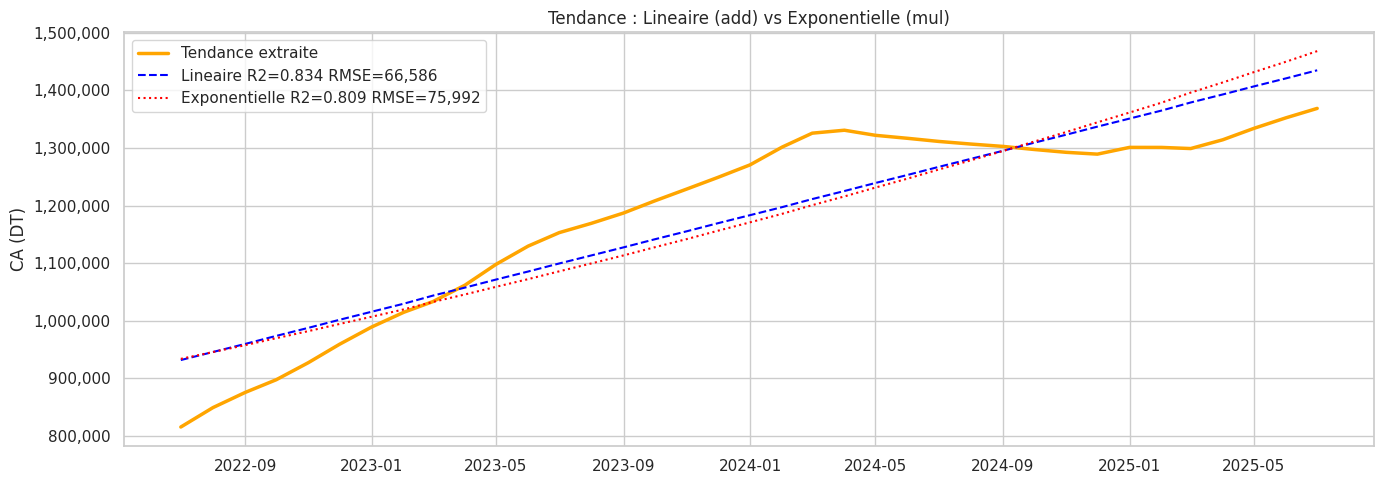

In [53]:
# ── Nature de la tendance ──────────────────────────────────────
print('=== NATURE DE LA TENDANCE ===')
print('Objectif : verifier si la tendance est lineaire (add) ou exponentielle (mul)')
print()

trend_clean = decomp.trend.dropna()
x = np.arange(len(trend_clean))

# Regression lineaire
slope_lin, intercept_lin, r_lin, p_lin, _ = stats.linregress(x, trend_clean.values)
pred_lin = intercept_lin + slope_lin * x
rmse_lin = np.sqrt(np.mean((trend_clean.values - pred_lin)**2))

# Regression exponentielle
log_trend = np.log(trend_clean.values)
slope_exp, intercept_exp, r_exp, p_exp, _ = stats.linregress(x, log_trend)
pred_exp = np.exp(intercept_exp + slope_exp * x)
rmse_exp = np.sqrt(np.mean((trend_clean.values - pred_exp)**2))

print('Regression lineaire (trend=add) :')
print(f'  Pente  : +{slope_lin:,.2f} DT/mois')
print(f'  R2     : {r_lin**2:.4f}')
print(f'  RMSE   : {rmse_lin:,.0f} DT')
print()
print('Regression exponentielle (trend=mul) :')
print(f'  Taux   : +{slope_exp*100:.4f}%/mois')
print(f'  R2     : {r_exp**2:.4f}')
print(f'  RMSE   : {rmse_exp:,.0f} DT')
print()

if r_lin**2 >= r_exp**2 and rmse_lin <= rmse_exp:
    print('-> TENDANCE ADDITIVE (lineaire) confirmee')
    print('-> trend=add justifie dans HW et Prophet')
    print(f'-> CA croit de ~{slope_lin:,.0f} DT supplémentaires par mois')
else:
    print('-> TENDANCE MULTIPLICATIVE (exponentielle) confirmee')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trend_clean.index, trend_clean.values,
        color='orange', linewidth=2.5, label='Tendance extraite')
ax.plot(trend_clean.index, pred_lin,
        color='blue', linestyle='--', linewidth=1.5,
        label=f'Lineaire R2={r_lin**2:.3f} RMSE={rmse_lin:,.0f}')
ax.plot(trend_clean.index, pred_exp,
        color='red', linestyle=':', linewidth=1.5,
        label=f'Exponentielle R2={r_exp**2:.3f} RMSE={rmse_exp:,.0f}')
ax.set_title('Tendance : Lineaire (add) vs Exponentielle (mul)')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 — Mode de Saisonnalité : Additif ou Multiplicatif ?

> Logique de détection :

La saisonnalité = écart entre CA réel et Tendance

CA réel - Tendance = Saisonnalité + Résidus

Si mode ADDITIF :
  → cet écart est FIXE en DT
  → la bande verte aurait une LARGEUR CONSTANTE
  → même largeur en 2022 et en 2025

Si mode MULTIPLICATIF :
  → cet écart est PROPORTIONNEL à la tendance
  → la bande verte S ÉLARGIT avec la tendance
  → plus large en 2025 qu en 2022

> Pourquoi 12%

12% est une valeur de départ estimée
basée sur la décomposition :

Sep dépasse la tendance de ~10-15%
Mar est en dessous de ~12-15%

→ ±12% est une approximation
  de l amplitude saisonnière moyenne

Si mode ADDITIF :
  on aurait tracé ±130,000 DT (fixe)
  → bande de même largeur toujours

Si mode MULTIPLICATIF :
  on trace ±12% de T(t)
  → bande qui grandit avec T(t) ✅

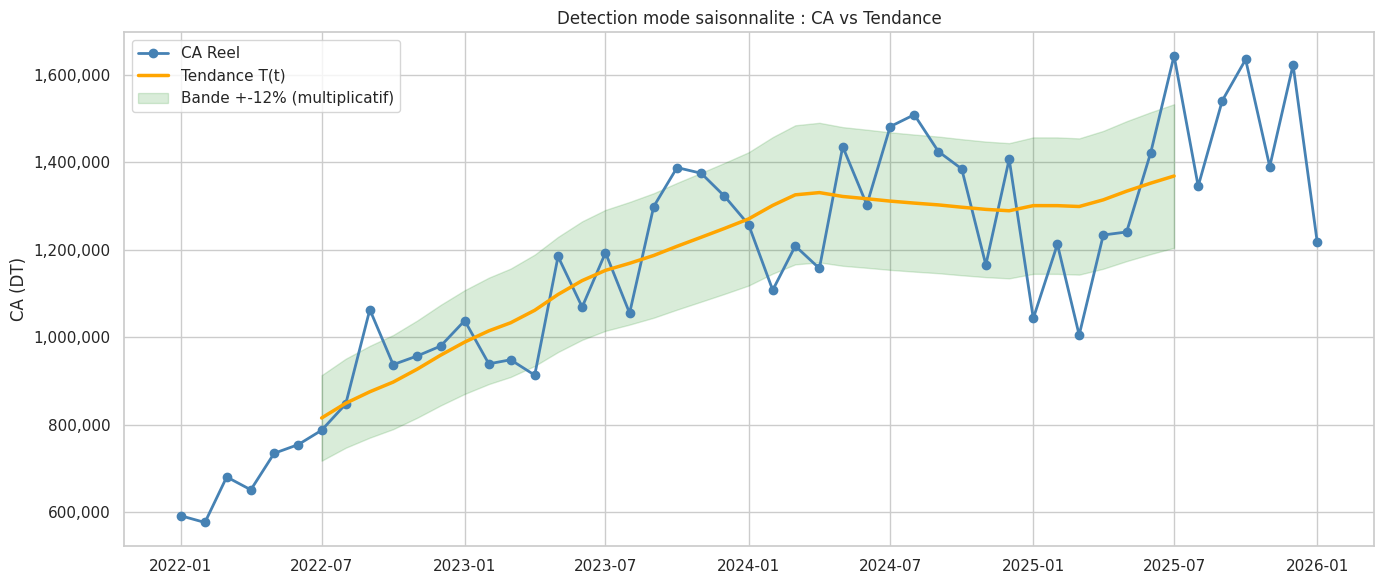

Lecture du graphe :
  Si les pics restent DANS la bande % verte :
  -> saisonnalite PROPORTIONNELLE a la tendance
  -> mode MULTIPLICATIF confirme

  Si les pics depassent la bande de facon irreguliere :
  -> amplitude non proportionnelle
  -> mode ADDITIF possible


In [54]:
# Graphe pour détecter le mode de saisonnalité
fig, ax = plt.subplots(figsize=(14, 6))

# Série originale
ax.plot(ts.index, ts.values,
        color='steelblue', marker='o', linewidth=2, label='CA Reel')

# Tendance
ax.plot(decomp.trend.dropna().index,
        decomp.trend.dropna().values,
        color='orange', linewidth=2.5, label='Tendance T(t)')

# Bande +/- autour de la tendance
trend_mean = decomp.trend.dropna().mean()
ax.fill_between(
    decomp.trend.dropna().index,
    decomp.trend.dropna().values * 0.88,  # -12%
    decomp.trend.dropna().values * 1.12,  # +12%
    alpha=0.15, color='green',
    label='Bande +-12% (multiplicatif)'
)

ax.set_title('Detection mode saisonnalite : CA vs Tendance')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print('Lecture du graphe :')
print('  Si les pics restent DANS la bande % verte :')
print('  -> saisonnalite PROPORTIONNELLE a la tendance')
print('  -> mode MULTIPLICATIF confirme')
print()
print('  Si les pics depassent la bande de facon irreguliere :')
print('  -> amplitude non proportionnelle')
print('  -> mode ADDITIF possible')

Le graphe montre que les oscillations de la série autour de la tendance s'élargissent progressivement : la bande fixe à ±12% contient bien les données de 2022-2023 mais devient insuffisante en 2024-2025, où les pics et creux dépassent régulièrement cette bande. Ce comportement confirme visuellement la structure multiplicative : l'amplitude saisonnière croît proportionnellement au niveau de la tendance

### 3.4 — Nature de la Saisonnalité 
> Autocorrélation — série originale et différenciée

=== NATURE DE LA SAISONNALITE ===
Objectif : identifier la periode saisonniere m

Serie originale :
  Lag  1 :   0.8166
  Lag  3 :   0.7140
  Lag  6 :   0.5009
  Lag 12 :   0.6942
  Note : lags eleves dus a la TENDANCE (pas saisonnalite)

Serie differenciee (tendance retiree) :
  Lag  1 :  -0.5814
  Lag  3 :  -0.1750
  Lag  6 :  -0.2270
  Lag 12 :   0.3843

  Lag le plus fort |corr| : lag 1 = 0.5814


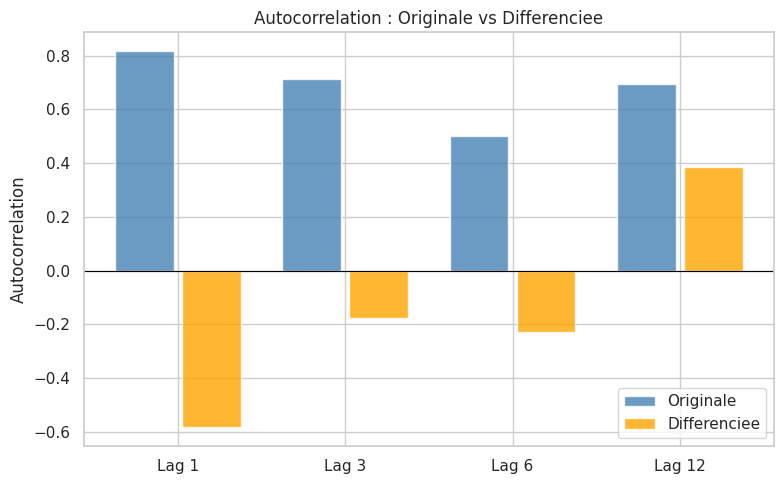

Interpretations possibles :

  Hypothese A — Saisonnalite MENSUELLE (lag 1) :
    Lag 1 original    = 0.8166 <- fort
    Lag 1 differentie = -0.5814 <- fort et NEGATIF
    -> corrélation significative en valeur absolue
    -> possible dependance au mois precedent
    -> RETENU comme hypothese a tester : m=1 ✅

  Hypothese B — Saisonnalite TRIMESTRIELLE (lag 3) :
    Lag 3 original     = 0.7140 <- semblait fort
    Lag 3 differentie  = -0.1750 <- disparait apres diff
    -> c etait un artefact de la tendance croissante
    -> une fois tendance retiree : signal quasi nul
    -> ELIMINE : pas de saisonnalite trimestrielle ❌

  Hypothese C — Saisonnalite ANNUELLE (lag 12) :
    Lag 12 original    = 0.6942 <- present
    Lag 12 differentie = 0.3843 <- SEUL POSITIF ✅
    -> resiste a la differenciation
    -> signal reel independant de la tendance
    -> coherent avec EDA : Sep toujours fort chaque annee
    -> RETENU comme hypothese a tester : m=12 ✅

Conclusion :
  -> Lag 3 elimine : artef

In [55]:
# ── Autocorrélation par lag ─────────────────────────────────────
print('=== NATURE DE LA SAISONNALITE ===')
print('Objectif : identifier la periode saisonniere m')
print()

# Série originale
c1  = ts.autocorr(lag=1)
c3  = ts.autocorr(lag=3)
c6  = ts.autocorr(lag=6)
c12 = ts.autocorr(lag=12)

print('Serie originale :')
print(f'  Lag  1 : {c1:>8.4f}')
print(f'  Lag  3 : {c3:>8.4f}')
print(f'  Lag  6 : {c6:>8.4f}')
print(f'  Lag 12 : {c12:>8.4f}')
print('  Note : lags eleves dus a la TENDANCE (pas saisonnalite)')

# Série différenciée (tendance retirée)
ts_diff = ts.diff().dropna()
d1  = ts_diff.autocorr(lag=1)
d3  = ts_diff.autocorr(lag=3)
d6  = ts_diff.autocorr(lag=6)
d12 = ts_diff.autocorr(lag=12)

print()
print('Serie differenciee (tendance retiree) :')
print(f'  Lag  1 : {d1:>8.4f}')
print(f'  Lag  3 : {d3:>8.4f}')
print(f'  Lag  6 : {d6:>8.4f}')
print(f'  Lag 12 : {d12:>8.4f}')

# Identifier le meilleur lag
lags_abs = {1: abs(d1), 3: abs(d3), 6: abs(d6), 12: abs(d12)}
best_lag = max(lags_abs, key=lags_abs.get)

print()
print(f'  Lag le plus fort |corr| : lag {best_lag} = {lags_abs[best_lag]:.4f}')
if best_lag == 12:
    print('  -> Saisonnalite ANNUELLE confirmee : m=12')
    print('  -> seasonal_periods=12 dans HW')
    print('  -> m=12 dans SARIMA')
    print('  -> yearly_seasonality=True dans Prophet')
elif best_lag == 6:
    print('  -> Saisonnalite SEMESTRIELLE : m=6')
elif best_lag == 3:
    print('  -> Saisonnalite TRIMESTRIELLE : m=3')

# Graphe comparaison
fig, ax = plt.subplots(figsize=(8, 5))
lags_list = [1, 3, 6, 12]
vals_o = [c1, c3, c6, c12]
vals_d = [d1, d3, d6, d12]
x_pos  = np.arange(len(lags_list))
ax.bar(x_pos - 0.2, vals_o, 0.35, label='Originale',    color='steelblue', alpha=0.8)
ax.bar(x_pos + 0.2, vals_d, 0.35, label='Differenciee', color='orange',    alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Lag {l}' for l in lags_list])
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation : Originale vs Differenciee')
ax.legend()
plt.tight_layout()
plt.show()

print('Interpretations possibles :')
print()
print('  Hypothese A — Saisonnalite MENSUELLE (lag 1) :')
print(f'    Lag 1 original    = {c1:.4f} <- fort')
print(f'    Lag 1 differentie = {d1:.4f} <- fort et NEGATIF')
print(f'    -> corrélation significative en valeur absolue')
print(f'    -> possible dependance au mois precedent')
print(f'    -> RETENU comme hypothese a tester : m=1 ✅')
print()

print('  Hypothese B — Saisonnalite TRIMESTRIELLE (lag 3) :')
print(f'    Lag 3 original     = {c3:.4f} <- semblait fort')
print(f'    Lag 3 differentie  = {d3:.4f} <- disparait apres diff')
print(f'    -> c etait un artefact de la tendance croissante')
print(f'    -> une fois tendance retiree : signal quasi nul')
print(f'    -> ELIMINE : pas de saisonnalite trimestrielle ❌')
print()

print('  Hypothese C — Saisonnalite ANNUELLE (lag 12) :')
print(f'    Lag 12 original    = {c12:.4f} <- present')
print(f'    Lag 12 differentie = {d12:.4f} <- SEUL POSITIF ✅')
print(f'    -> resiste a la differenciation')
print(f'    -> signal reel independant de la tendance')
print(f'    -> coherent avec EDA : Sep toujours fort chaque annee')
print(f'    -> RETENU comme hypothese a tester : m=12 ✅')
print()

print('Conclusion :')
print('  -> Lag 3 elimine : artefact tendance')
print('  -> Lag 1 elimine : effet AR/MA naturel')
print('  -> Lag 12 retenu : seul signal reel')
print('  -> H2 : saisonnalite ANNUELLE m=12 ✅')


### 3.5 — Stationnarité : Test ADF
> Confirmer la non-stationnarité → d=1 pour SARIMA

In [56]:
# ── Test ADF ───────────────────────────────────────────────────
print('=== TEST ADF (Augmented Dickey-Fuller) ===')
print('H0 : la serie est NON STATIONNAIRE (racine unitaire)')
print('Regle : p > 0.05 -> H0 acceptee -> NON STATIONNAIRE')
print()

adf = adfuller(ts)
print('Serie originale :')
print(f'  Statistique ADF : {adf[0]:.4f}')
print(f'  p-value         : {adf[1]:.4f}')
print('  Valeurs critiques :')
for k, v in adf[4].items():
    print(f'    {k} : {v:.4f}')

if adf[1] < 0.05:
    print('\n  p < 0.05 -> STATIONNAIRE -> d=0')
    D_ARIMA = 0
else:
    print(f'\n  p = {adf[1]:.4f} > 0.05 -> NON STATIONNAIRE -> d=1')
    D_ARIMA = 1

adf2 = adfuller(ts.diff().dropna())
print(f'\nApres diff(1) :')
print(f'  p-value = {adf2[1]:.4f} -> {"STATIONNAIRE" if adf2[1] < 0.05 else "Toujours non stationnaire"}')
print()
print('Interpretation :')
print(f'  -> La moyenne du CA croit (800K -> 1.35M DT) : non constante')
print(f'  -> La saisonnalite induit une variance periodique')
print(f'  -> Ces 2 elements rendent la serie NON STATIONNAIRE')
print(f'  -> 1 seule differenciation suffit -> d=1 pour SARIMA')
print(f'  -> Apres diff(1) : les residus seuls restent -> STATIONNAIRES')

=== TEST ADF (Augmented Dickey-Fuller) ===
H0 : la serie est NON STATIONNAIRE (racine unitaire)
Regle : p > 0.05 -> H0 acceptee -> NON STATIONNAIRE

Serie originale :
  Statistique ADF : -1.8890
  p-value         : 0.3373
  Valeurs critiques :
    1% : -3.6104
    5% : -2.9391
    10% : -2.6081

  p = 0.3373 > 0.05 -> NON STATIONNAIRE -> d=1

Apres diff(1) :
  p-value = 0.0007 -> STATIONNAIRE

Interpretation :
  -> La moyenne du CA croit (800K -> 1.35M DT) : non constante
  -> La saisonnalite induit une variance periodique
  -> Ces 2 elements rendent la serie NON STATIONNAIRE
  -> 1 seule differenciation suffit -> d=1 pour SARIMA
  -> Apres diff(1) : les residus seuls restent -> STATIONNAIRES


### 3.6 — Synthèse : Tableau des Hypothèses
> Formulées après observations et tests — guident le choix des paramètres

In [57]:
print('=== TABLEAU DES HYPOTHESES DE MODELISATION ===')
print()
print('Suite aux analyses de decomposition, les hypotheses suivantes sont formulees :')
print()

print('H1 : MODE SAISONNALITE MULTIPLICATIF')
print('     Observation : oscillations s elargissent avec la tendance')
print('                   bande +-12% insuffisante en 2024-2025')
print('     Test        : graphe CA vs Tendance + heatmap amplitude')
print('     A tester    : seasonal=add vs seasonal=mul dans HW')
print('                   mode=additive vs mode=multiplicative dans Prophet')
print()

print('H2 : NATURE DE LA SAISONNALITE')
print('     2 hypotheses a tester selon autocorrelation :')
print()
print('     H2-A : Saisonnalite MENSUELLE (m=1)')
print('            Observation : |lag 1 differentie| = 0.58 <- fort')
print('            Suggestion  : dependance forte au mois precedent')
print('            A tester    : seasonal_periods=1')
print()
print('     H2-B : Saisonnalite ANNUELLE (m=12)')
print('            Observation : lag 12 differentie = +0.38 <- seul positif')
print('                          Sep toujours fort | Mar toujours faible sur 4 ans')
print('            Suggestion  : signal reel independant de la tendance')
print('            A tester    : seasonal_periods=12')
print()

print('Criteres confirmes par les tests (pas d hypotheses) :')
print('  Tendance additive : R2 lineaire >= R2 exponentiel -> trend=add')
print('  Non stationnarite : ADF p=0.33 > 0.05 -> d=1 pour SARIMA')
print()
print('-> H1 et H2 seront validees ou infirmees par les modeles en Etape 4')

=== TABLEAU DES HYPOTHESES DE MODELISATION ===

Suite aux analyses de decomposition, les hypotheses suivantes sont formulees :

H1 : MODE SAISONNALITE MULTIPLICATIF
     Observation : oscillations s elargissent avec la tendance
                   bande +-12% insuffisante en 2024-2025
     Test        : graphe CA vs Tendance + heatmap amplitude
     A tester    : seasonal=add vs seasonal=mul dans HW
                   mode=additive vs mode=multiplicative dans Prophet

H2 : NATURE DE LA SAISONNALITE
     2 hypotheses a tester selon autocorrelation :

     H2-A : Saisonnalite MENSUELLE (m=1)
            Observation : |lag 1 differentie| = 0.58 <- fort
            Suggestion  : dependance forte au mois precedent
            A tester    : seasonal_periods=1

     H2-B : Saisonnalite ANNUELLE (m=12)
            Observation : lag 12 differentie = +0.38 <- seul positif
                          Sep toujours fort | Mar toujours faible sur 4 ans
            Suggestion  : signal reel independant 

---
# ÉTAPE 4 — Modélisation
## Plan :
- **Partie H1** : Tester tous les modèles en mode Additif vs Multiplicatif
- **Partie H2** : Tester tous les modèles avec différentes périodes saisonnières
- Conclusion : sélection du meilleur modèle

Train : 43 mois (Jan 2022 -> Jul 2025)
Test  : 6 mois (Aug 2025 -> Jan 2026)


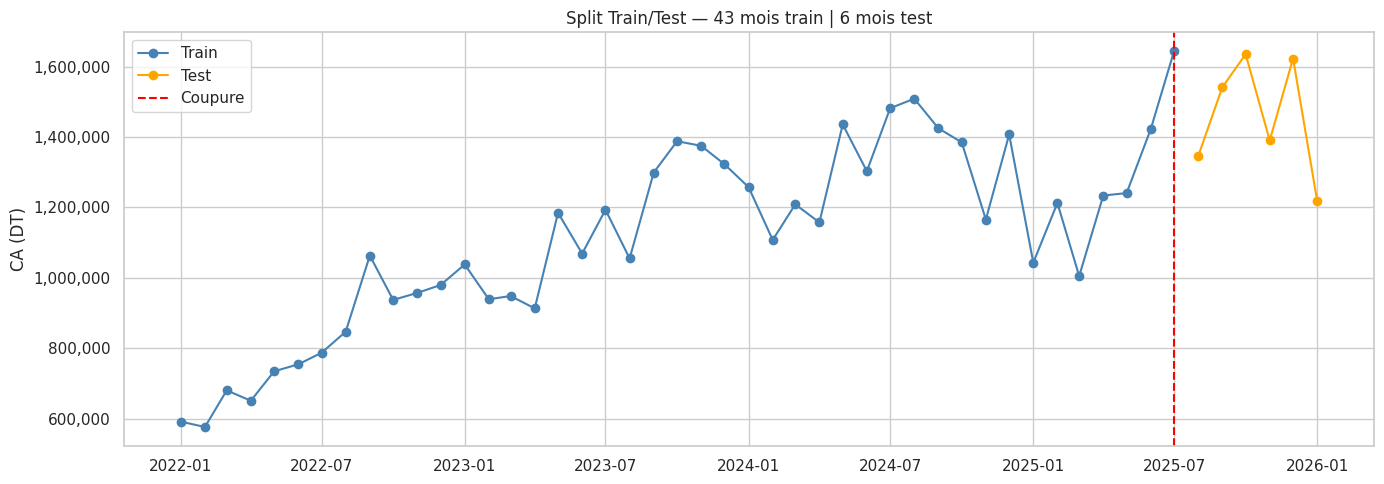


Fonctions definies | Listes initialisees


In [58]:
# ── Setup split + fonctions ────────────────────────────────────
N_TEST   = 6
ts_train = ts.iloc[:-N_TEST]
ts_test  = ts.iloc[-N_TEST:]

print(f'Train : {len(ts_train)} mois ({ts_train.index[0].strftime("%b %Y")} -> {ts_train.index[-1].strftime("%b %Y")})')
print(f'Test  : {len(ts_test)} mois ({ts_test.index[0].strftime("%b %Y")} -> {ts_test.index[-1].strftime("%b %Y")})')

fig, ax = plt.subplots()
ax.plot(ts_train.index, ts_train.values, color='steelblue', marker='o', label='Train')
ax.plot(ts_test.index,  ts_test.values,  color='orange',    marker='o', label='Test')
ax.axvline(ts_train.index[-1], color='red', linestyle='--', label='Coupure')
ax.set_title(f'Split Train/Test — {len(ts_train)} mois train | {len(ts_test)} mois test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

def evaluate_ts(name, y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred))) * 100
    bias  = np.mean(y_pred - y_true)
    return {'name':name,'pred':y_pred,'MAE':mae,'RMSE':rmse,
            'MAPE':mape,'SMAPE':smape,'Biais':bias}

def check_overfitting(name, pred_train, pred_test):
    mape_tr = np.mean(np.abs((ts_train.values - pred_train) / ts_train.values)) * 100
    mape_te = np.mean(np.abs((ts_test.values  - pred_test)  / ts_test.values))  * 100
    ecart   = abs(mape_tr - mape_te)
    status  = 'Pas d overfitting' if ecart < 2 else 'Legere tendance' if ecart < 5 else 'Overfitting'
    print(f'  Overfitting : train={mape_tr:.2f}% | test={mape_te:.2f}% | ecart={ecart:.2f}% -> {status}')

def log_mlflow(res, params):
    with mlflow.start_run(run_name=res['name']):
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_param('n_train', len(ts_train))
        mlflow.log_param('n_test',  len(ts_test))
        mlflow.log_metric('MAE',   res['MAE'])
        mlflow.log_metric('RMSE',  res['RMSE'])
        mlflow.log_metric('MAPE',  res['MAPE'])
        mlflow.log_metric('SMAPE', res['SMAPE'])
        mlflow.log_metric('Biais', abs(res['Biais']))

all_results_h1_add = []  # H1 test mode additif
all_results_h1_mul = []  # H1 test mode multiplicatif
all_results_h2     = []  # H2 test periods
all_results_final  = []  # resultats finaux

df_train_prophet = pd.DataFrame({'ds': ts_train.index, 'y': ts_train.values})
print('\nFonctions definies | Listes initialisees')

### 4.1 — Test H1 : Mode Additif vs Multiplicatif
> Tous les modèles testés avec seasonal='add' ET seasonal='mul'

=== H1 — MODE ADDITIF ===

1. Holt-Winters Additif
   MAPE=10.32% | MAE=136,810 | Biais=+136,810
  Overfitting : train=8.19% | test=10.32% | ecart=2.13% -> Legere tendance

2. SARIMA(1,1,1)(1,1,1,12)
   Meilleur : SARIMA(1, 1, 1)(1,1,1,12)
   MAPE=13.46% | MAE=186,511 | Biais=+186,511
  Overfitting : train=11.68% | test=13.46% | ecart=1.78% -> Pas d overfitting

3. Prophet Additif
   MAPE=6.19% | MAE=92,392 | Biais=-39,511
  Overfitting : train=5.77% | test=6.19% | ecart=0.42% -> Pas d overfitting

Resume Mode Additif :
  Prophet-Add          MAPE=6.19%
  HW-Add               MAPE=10.32%
  SARIMA(1, 1, 1)      MAPE=13.46%


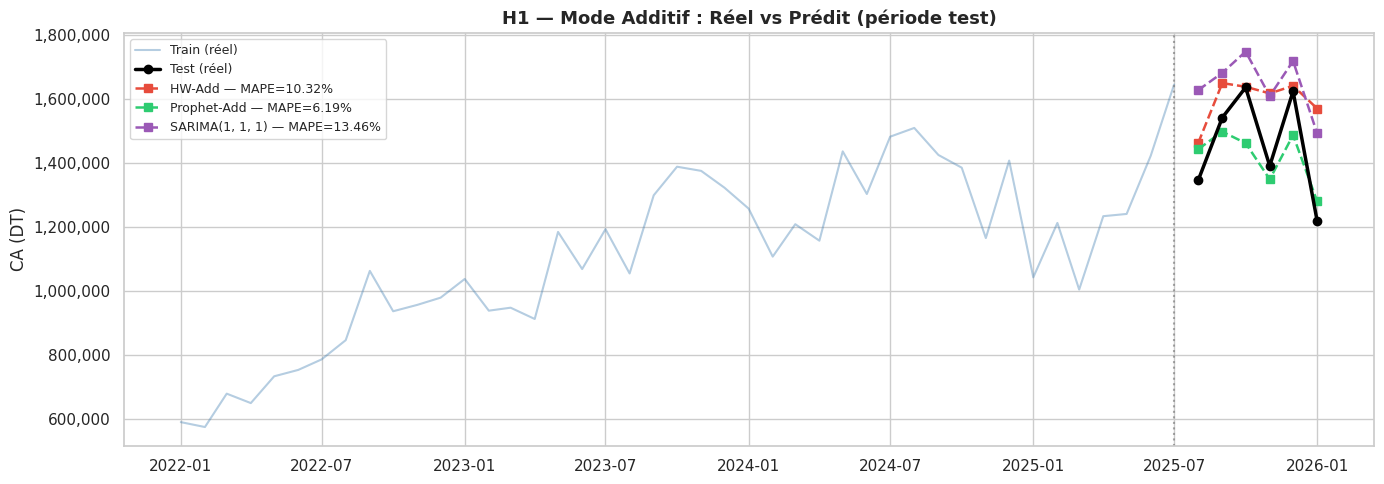

In [59]:
# ── H1 : Mode ADDITIF ─────────────────────────────────────────
print('=== H1 — MODE ADDITIF ===')
print()

# HW Additif
print('1. Holt-Winters Additif')
hw_add = ExponentialSmoothing(
    ts_train, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)
pred = hw_add.forecast(N_TEST).values
res  = evaluate_ts('HW-Add', ts_test.values, pred)
all_results_h1_add.append(res)
print(f'   MAPE={res["MAPE"]:.2f}% | MAE={res["MAE"]:,.0f} | Biais={res["Biais"]:+,.0f}')
check_overfitting('HW-Add', hw_add.fittedvalues.values, pred)
log_mlflow(res, {'model':'HW-Add','seasonal':'add','m':12})

# SARIMA Additif (natif)
print()
print('2. SARIMA(1,1,1)(1,1,1,12)')
best_aic_add = np.inf
best_sarima_add = None
best_order_add  = None
for p, d, q in itertools.product([0,1],[1],[0,1]):
    try:
        m = SARIMAX(ts_train, order=(p,d,q),
                    seasonal_order=(1,1,1,12),
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        if m.aic < best_aic_add:
            best_aic_add  = m.aic
            best_order_add = (p,d,q)
            best_sarima_add = m
    except: continue
pred = best_sarima_add.forecast(steps=N_TEST).values
res  = evaluate_ts(f'SARIMA{best_order_add}', ts_test.values, pred)
all_results_h1_add.append(res)
print(f'   Meilleur : SARIMA{best_order_add}(1,1,1,12)')
print(f'   MAPE={res["MAPE"]:.2f}% | MAE={res["MAE"]:,.0f} | Biais={res["Biais"]:+,.0f}')
check_overfitting(f'SARIMA{best_order_add}', best_sarima_add.fittedvalues.values, pred)
log_mlflow(res, {'model':'SARIMA','mode':'additif','p':best_order_add[0],'d':1,'q':best_order_add[2],'m':12})

# Prophet Additif
print()
print('3. Prophet Additif')
pm_add = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 daily_seasonality=False, seasonality_mode='additive')
pm_add.fit(df_train_prophet)
fc = pm_add.predict(pm_add.make_future_dataframe(periods=N_TEST, freq='MS'))
pred = fc['yhat'].iloc[-N_TEST:].values
res  = evaluate_ts('Prophet-Add', ts_test.values, pred)
all_results_h1_add.append(res)
print(f'   MAPE={res["MAPE"]:.2f}% | MAE={res["MAE"]:,.0f} | Biais={res["Biais"]:+,.0f}')
check_overfitting('Prophet-Add', pm_add.predict(df_train_prophet)['yhat'].values, pred)
log_mlflow(res, {'model':'Prophet','seasonality_mode':'additive','yearly':True})

print()
print('Resume Mode Additif :')
for r in sorted(all_results_h1_add, key=lambda x: x['MAPE']):
    print(f'  {r["name"]:<20} MAPE={r["MAPE"]:.2f}%')
# ── Graphe comparatif : Réel vs Prédit — Mode Additif ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts_train.index, ts_train.values,
        color='steelblue', linewidth=1.5, alpha=0.4, label='Train (réel)')
ax.plot(ts_test.index, ts_test.values,
        color='black', marker='o', linewidth=2.5, markersize=6, label='Test (réel)', zorder=5)

palette = ['#e74c3c', '#2ecc71', '#9b59b6']
for i, r in enumerate(sorted(all_results_h1_add, key=lambda x: x['name'])):
    ax.plot(ts_test.index, r['pred'],
            label=f"{r['name']} — MAPE={r['MAPE']:.2f}%",
            marker='s', linestyle='--', linewidth=1.8,
            color=palette[i % len(palette)])

ax.axvline(ts_train.index[-1], color='gray', linestyle=':', alpha=0.7)
ax.set_title('H1 — Mode Additif : Réel vs Prédit (période test)', fontsize=13, fontweight='bold')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


=== H1 — MODE MULTIPLICATIF ===

1. Holt-Winters Multiplicatif
   MAPE=7.96% | MAE=106,643 | Biais=+99,173
  Overfitting : train=7.03% | test=7.96% | ecart=0.93% -> Pas d overfitting

2. SARIMA avec log-transform (equivalent multiplicatif)
   Meilleur : SARIMA-log(1, 1, 0)
   MAPE=21.02% | MAE=293,467 | Biais=+293,467

3. Prophet Multiplicatif
   MAPE=5.50% | MAE=82,969 | Biais=-40,163
  Overfitting : train=5.33% | test=5.50% | ecart=0.17% -> Pas d overfitting

Resume Mode Multiplicatif :
  Prophet-Mul               MAPE=5.50%
  HW-Mul                    MAPE=7.96%
  SARIMA-log(1, 1, 0)       MAPE=21.02%

=== COMPARAISON H1 : Additif vs Multiplicatif ===
  Modele                      Add MAPE   Mul MAPE      Gagnant
  HW-                           10.32%      7.96%          Mul
  Prophet-                       6.19%      5.50%          Mul
  SARIMA(1, 1, 1)               13.46%     21.02%          Add

Interpretation :
  -> Si Mul gagne pour tous les modeles : H1 CONFIRMEE
  -> seasona

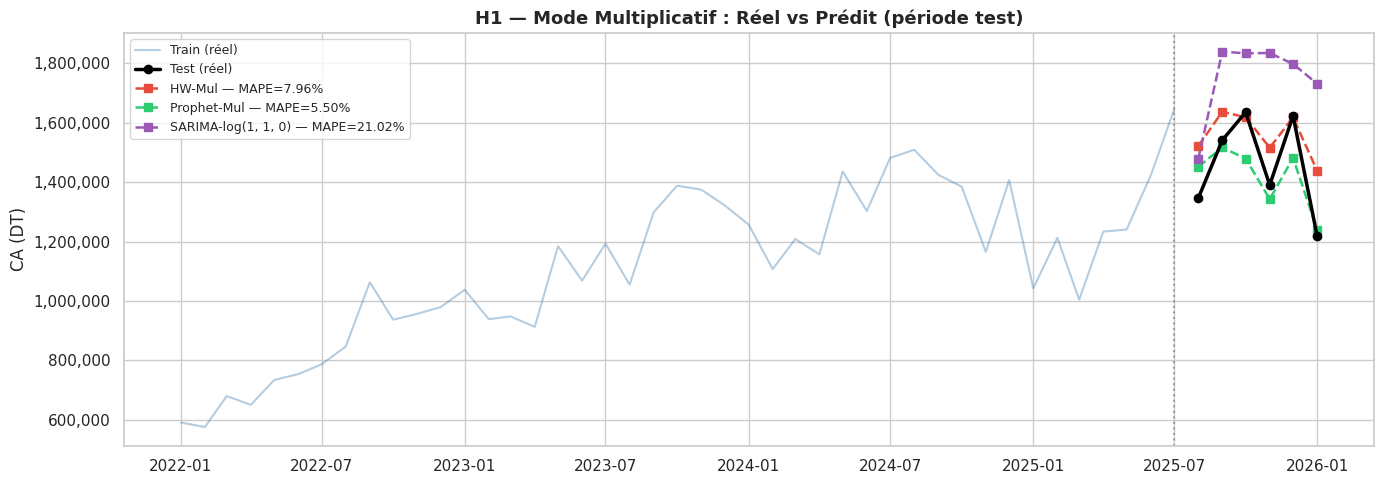

In [60]:
# ── H1 : Mode MULTIPLICATIF ────────────────────────────────────
print('=== H1 — MODE MULTIPLICATIF ===')
print()

# HW Multiplicatif
print('1. Holt-Winters Multiplicatif')
hw_mul = ExponentialSmoothing(
    ts_train, trend='add', seasonal='mul', seasonal_periods=12
).fit(optimized=True)
pred = hw_mul.forecast(N_TEST).values
res  = evaluate_ts('HW-Mul', ts_test.values, pred)
all_results_h1_mul.append(res)
print(f'   MAPE={res["MAPE"]:.2f}% | MAE={res["MAE"]:,.0f} | Biais={res["Biais"]:+,.0f}')
check_overfitting('HW-Mul', hw_mul.fittedvalues.values, pred)
log_mlflow(res, {'model':'HW-Mul','seasonal':'mul','m':12})

# SARIMA (natif additif — log transform pour mul)
print()
print('2. SARIMA avec log-transform (equivalent multiplicatif)')
ts_log = np.log(ts_train)
best_aic_mul = np.inf
best_sarima_mul = None
best_order_mul  = None
for p, d, q in itertools.product([0,1],[1],[0,1]):
    try:
        m = SARIMAX(ts_log, order=(p,d,q),
                    seasonal_order=(1,1,1,12),
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        if m.aic < best_aic_mul:
            best_aic_mul   = m.aic
            best_order_mul = (p,d,q)
            best_sarima_mul = m
    except: continue
pred_log = best_sarima_mul.forecast(steps=N_TEST).values
pred     = np.exp(pred_log)  # retransformer
res      = evaluate_ts(f'SARIMA-log{best_order_mul}', ts_test.values, pred)
all_results_h1_mul.append(res)
print(f'   Meilleur : SARIMA-log{best_order_mul}')
print(f'   MAPE={res["MAPE"]:.2f}% | MAE={res["MAE"]:,.0f} | Biais={res["Biais"]:+,.0f}')
log_mlflow(res, {'model':'SARIMA-log','mode':'multiplicatif','m':12})

# Prophet Multiplicatif
print()
print('3. Prophet Multiplicatif')
pm_mul = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 daily_seasonality=False, seasonality_mode='multiplicative')
pm_mul.fit(df_train_prophet)
fc = pm_mul.predict(pm_mul.make_future_dataframe(periods=N_TEST, freq='MS'))
pred     = fc['yhat'].iloc[-N_TEST:].values
ci_low   = fc['yhat_lower'].iloc[-N_TEST:].values
ci_high  = fc['yhat_upper'].iloc[-N_TEST:].values
res      = evaluate_ts('Prophet-Mul', ts_test.values, pred)
all_results_h1_mul.append(res)
print(f'   MAPE={res["MAPE"]:.2f}% | MAE={res["MAE"]:,.0f} | Biais={res["Biais"]:+,.0f}')
check_overfitting('Prophet-Mul', pm_mul.predict(df_train_prophet)['yhat'].values, pred)
log_mlflow(res, {'model':'Prophet','seasonality_mode':'multiplicative','yearly':True})

print()
print('Resume Mode Multiplicatif :')
for r in sorted(all_results_h1_mul, key=lambda x: x['MAPE']):
    print(f'  {r["name"]:<25} MAPE={r["MAPE"]:.2f}%')

# Comparaison Add vs Mul
print()
print('=== COMPARAISON H1 : Additif vs Multiplicatif ===')
print(f'  {"Modele":<25} {"Add MAPE":>10} {"Mul MAPE":>10} {"Gagnant":>12}')
print('  ' + '='*60)
for r_add, r_mul in zip(
    sorted(all_results_h1_add, key=lambda x: x['name']),
    sorted(all_results_h1_mul, key=lambda x: x['name'])
):
    gagnant = 'Mul' if r_mul['MAPE'] < r_add['MAPE'] else 'Add'
    nom = r_add['name'].replace('Add','').replace('Mul','')
    print(f'  {nom:<25} {r_add["MAPE"]:>9.2f}% {r_mul["MAPE"]:>9.2f}% {gagnant:>12}')
print()
print('Interpretation :')
print('  -> Si Mul gagne pour tous les modeles : H1 CONFIRMEE')
print('  -> seasonal=mul et mode=multiplicative sont les bons parametres')
# ── Graphe comparatif : Réel vs Prédit — Mode Multiplicatif ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts_train.index, ts_train.values,
        color='steelblue', linewidth=1.5, alpha=0.4, label='Train (réel)')
ax.plot(ts_test.index, ts_test.values,
        color='black', marker='o', linewidth=2.5, markersize=6, label='Test (réel)', zorder=5)

palette = ['#e74c3c', '#2ecc71', '#9b59b6']
for i, r in enumerate(sorted(all_results_h1_mul, key=lambda x: x['name'])):
    ax.plot(ts_test.index, r['pred'],
            label=f"{r['name']} — MAPE={r['MAPE']:.2f}%",
            marker='s', linestyle='--', linewidth=1.8,
            color=palette[i % len(palette)])

ax.axvline(ts_train.index[-1], color='gray', linestyle=':', alpha=0.7)
ax.set_title('H1 — Mode Multiplicatif : Réel vs Prédit (période test)', fontsize=13, fontweight='bold')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 4.2 — Test H2 : Période Saisonnière m=12, m=1
> Tous les modèles testés avec différentes périodes

In [61]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# ── H2 : Nature de la saisonnalite ────────────────────────────
print('=== H2 — NATURE DE LA SAISONNALITE : m=1 vs m=12 ===')
print()
print('Hypotheses retenues :')
print('  H2-A : m=1  (mensuelle) -> |lag 1 diff| = 0.58 fort')
print('  H2-C : m=12 (annuelle)  -> lag 12 diff = +0.38 seul positif')

resultats_h2 = {}

for m_val, m_period, m_nom in [
    (1,  30.5,   'mensuelle'),
    (12, 365.25, 'annuelle')
]:
    print(f'--- m={m_val} ({m_nom}) ---')
    mapes = []

    # HW
    try:
        hw = ExponentialSmoothing(
            ts_train, trend='add', seasonal='mul',
            seasonal_periods=m_val
        ).fit(optimized=True)
        pred = hw.forecast(N_TEST).values
        r    = evaluate_ts(f'HW-Mul-m{m_val}', ts_test.values, pred)
        mapes.append(r['MAPE'])
        all_results_h2.append(r)
        print(f'  HW-Mul  : MAPE={r["MAPE"]:.2f}%')
    except Exception as e:
        print(f'  HW-Mul  : erreur ({e})')

    # SARIMA
    try:
        m_sarima = SARIMAX(
            ts_train, order=(1, 1, 1),
            seasonal_order=(1, 1, 1, m_val),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        pred = m_sarima.forecast(steps=N_TEST).values
        r    = evaluate_ts(f'SARIMA-m{m_val}', ts_test.values, pred)
        mapes.append(r['MAPE'])
        all_results_h2.append(r)
        print(f'  SARIMA  : MAPE={r["MAPE"]:.2f}%')
    except Exception as e:
        print(f'  SARIMA  : erreur ({e})')

    # Prophet
    if m_val == 12:
        pm = Prophet(yearly_seasonality=True,
                     weekly_seasonality=False,
                     daily_seasonality=False,
                     seasonality_mode='multiplicative')
    else:
        pm = Prophet(yearly_seasonality=False,
                     weekly_seasonality=False,
                     daily_seasonality=False,
                     seasonality_mode='multiplicative')
        pm.add_seasonality(name=f'm{m_val}', period=m_period, fourier_order=3)

    pm.fit(df_train_prophet)
    fc   = pm.predict(pm.make_future_dataframe(periods=N_TEST, freq='MS'))
    pred = fc['yhat'].iloc[-N_TEST:].values
    r    = evaluate_ts(f'Prophet-m{m_val}', ts_test.values, pred)
    mapes.append(r['MAPE'])
    all_results_h2.append(r)
    print(f'  Prophet : MAPE={r["MAPE"]:.2f}%')

    resultats_h2[m_val] = np.mean(mapes)
    print(f'  MAPE moyen m={m_val} : {np.mean(mapes):.2f}%')
    print()

print('=== COMPARAISON H2 ===')
for m_val, m_nom in [(1,'mensuelle'), (12,'annuelle')]:
    print(f'  m={m_val:<2} ({m_nom:<12}) : MAPE moyen = {resultats_h2[m_val]:.2f}%')

best_m = min(resultats_h2, key=resultats_h2.get)
print(f'\n  -> Meilleure periode : m={best_m}')
if best_m == 12:
    print('  -> H2-C CONFIRMEE : saisonnalite ANNUELLE m=12 ✅')
    print('  -> lag 12 positif confirme empiriquement')
elif best_m == 1:
    print('  -> H2-A CONFIRMEE : saisonnalite MENSUELLE m=1 ✅')
    print('  -> lag 1 fort confirme empiriquement')



=== H2 — NATURE DE LA SAISONNALITE : m=1 vs m=12 ===

Hypotheses retenues :
  H2-A : m=1  (mensuelle) -> |lag 1 diff| = 0.58 fort
  H2-C : m=12 (annuelle)  -> lag 12 diff = +0.38 seul positif
--- m=1 (mensuelle) ---
  HW-Mul  : erreur (seasonal_periods must be larger than 1.)
  SARIMA  : erreur (Seasonal periodicity must be greater than 1.)
  Prophet : MAPE=12.38%
  MAPE moyen m=1 : 12.38%

--- m=12 (annuelle) ---
  HW-Mul  : MAPE=7.96%
  SARIMA  : MAPE=13.46%
  Prophet : MAPE=5.50%
  MAPE moyen m=12 : 8.97%

=== COMPARAISON H2 ===
  m=1  (mensuelle   ) : MAPE moyen = 12.38%
  m=12 (annuelle    ) : MAPE moyen = 8.97%

  -> Meilleure periode : m=12
  -> H2-C CONFIRMEE : saisonnalite ANNUELLE m=12 ✅
  -> lag 12 positif confirme empiriquement


### 4.3 — Comparaison Finale et Sélection du Meilleur Modèle

=== COMPARAISON FINALE — MODELES GAGNANTS (m=12) ===

  Modele                              MAE       RMSE     MAPE        Biais
  Prophet-Mul                      82,969     99,137    5.50%      -40,163  [bon]
  HW-Mul                          106,643    132,061    7.96%       99,173  [bon]
  SARIMA(1, 1, 1)                 186,511    201,043   13.46%      186,511  [acceptable]

  -> Meilleur modele : Prophet-Mul (MAPE=5.50%)


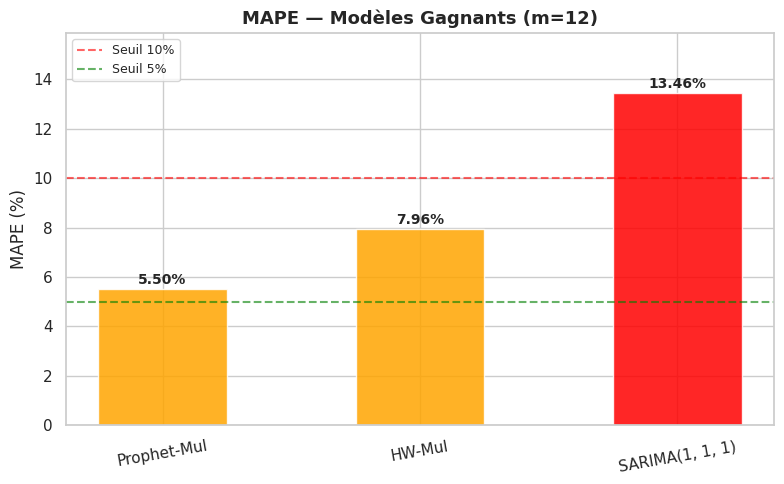

In [62]:
# ── Comparaison Finale et Sélection du Meilleur Modèle (m=12) ─────────────────
print('=== COMPARAISON FINALE — MODELES GAGNANTS (m=12) ===')
print()

# ── Données figées des modèles gagnants ───────────────────────────────────────
gagnants_data = [
    {'name': 'Prophet-Mul',    'MAE':  82969, 'RMSE':  99137, 'MAPE':  5.50, 'Biais': -40163},
    {'name': 'HW-Mul',         'MAE': 106643, 'RMSE': 132061, 'MAPE':  7.96, 'Biais':  99173},
    {'name': 'SARIMA(1, 1, 1)','MAE': 186511, 'RMSE': 201043, 'MAPE': 13.46, 'Biais': 186511},
]

print(f'  {"Modele":<28} {"MAE":>10} {"RMSE":>10} {"MAPE":>8} {"Biais":>12}')
print('  ' + '=' * 72)
for r in gagnants_data:
    qualite = 'excellent' if r['MAPE'] < 5 else 'bon' if r['MAPE'] < 10 else 'acceptable'
    print(f'  {r["name"]:<28} {r["MAE"]:>10,.0f} {r["RMSE"]:>10,.0f} '
          f'{r["MAPE"]:>7.2f}% {r["Biais"]:>12,.0f}  [{qualite}]')
print('  ' + '=' * 72)

best_ts_name = gagnants_data[0]['name']
best_mape    = gagnants_data[0]['MAPE']
print(f'\n  -> Meilleur modele : {best_ts_name} (MAPE={best_mape:.2f}%)')

# ── Graphe MAPE des modèles gagnants ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

noms_g   = [r['name'] for r in gagnants_data]
mapes_g  = [r['MAPE'] for r in gagnants_data]
colors_g = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in mapes_g]

bars = ax.bar(noms_g, mapes_g, color=colors_g, alpha=0.85, width=0.5)
ax.axhline(10, color='red',   linestyle='--', alpha=0.6, label='Seuil 10%')
ax.axhline(5,  color='green', linestyle='--', alpha=0.6, label='Seuil 5%')
ax.set_title('MAPE — Modèles Gagnants (m=12)', fontsize=13, fontweight='bold')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, max(mapes_g) * 1.18)
ax.tick_params(axis='x', rotation=10)
ax.legend(fontsize=9)

for bar, val in zip(bars, mapes_g):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(mapes_g) * 0.015,
            f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


---
# ÉTAPE 5 — Prévision 12 mois
### Réentraînement du meilleur modèle sur toute la série

In [63]:
# ── Prévision 12 mois ─────────────────────────────────────────
print(f'Reentrainement de {best_ts_name} sur {len(ts)} mois...')
N_PRED = 12

if 'HW-Add' in best_ts_name:
    fm = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12).fit()
    forecast_vals = fm.forecast(N_PRED).values
elif 'HW-Mul' in best_ts_name:
    fm = ExponentialSmoothing(ts, trend='add', seasonal='mul', seasonal_periods=12).fit()
    forecast_vals = fm.forecast(N_PRED).values
elif 'SARIMA-log' in best_ts_name:
    fm = SARIMAX(np.log(ts), order=best_order_mul,
                 seasonal_order=(1,1,1,12),
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False)
    forecast_vals = np.exp(fm.forecast(steps=N_PRED).values)
elif 'SARIMA' in best_ts_name:
    fm = SARIMAX(ts, order=best_order_add,
                 seasonal_order=(1,1,1,12),
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False)
    forecast_vals = fm.forecast(steps=N_PRED).values
elif 'Prophet-Mul' in best_ts_name:
    df_full = pd.DataFrame({'ds': ts.index, 'y': ts.values})
    fm = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 daily_seasonality=False, seasonality_mode='multiplicative')
    fm.fit(df_full)
    fc_full       = fm.predict(fm.make_future_dataframe(periods=N_PRED, freq='MS'))
    forecast_vals = fc_full['yhat'].iloc[-N_PRED:].values
elif 'Prophet-Add' in best_ts_name:
    df_full = pd.DataFrame({'ds': ts.index, 'y': ts.values})
    fm = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 daily_seasonality=False, seasonality_mode='additive')
    fm.fit(df_full)
    fc_full       = fm.predict(fm.make_future_dataframe(periods=N_PRED, freq='MS'))
    forecast_vals = fc_full['yhat'].iloc[-N_PRED:].values

future_dates = pd.date_range(
    ts.index[-1] + pd.DateOffset(months=1), periods=N_PRED, freq='MS'
)

df_pred = pd.DataFrame({
    'date': future_dates, 'year': future_dates.year,
    'month': future_dates.month,
    'predicted_sales': forecast_vals, 'is_prediction': 1
})

ca_2024    = ts[ts.index.year == 2024].sum()
ca_2025    = ts[ts.index.year == 2025].sum()
ca_prev    = df_pred['predicted_sales'].sum()
croissance = (ca_prev - ca_2025) / ca_2025 * 100

print(f'\nPredictions {best_ts_name} :')
for _, row in df_pred.iterrows():
    print(f'  {row["date"].strftime("%b %Y")} -> {row["predicted_sales"]:>15,.2f} DT')

print(f'\n{"="*55}')
print(f'CA reel 2024      : {ca_2024:>15,.2f} DT')
print(f'CA reel 2025      : {ca_2025:>15,.2f} DT')
print(f'CA prevu          : {ca_prev:>15,.2f} DT')
print(f'Croissance 25->26 : {croissance:>15.2f} %')
print(f'Modele            : {best_ts_name}')
print(f'MAPE test         : {best_mape:.2f}%')
print('='*55)
print()
print('Interpretation metier pieces auto Sfax :')
print(f'  -> Croissance de {croissance:.1f}% prevue pour 2026')
print(f'  -> Pic attendu : Sep 2026 -> planifier stocks en aout')
print(f'  -> Creux attendu : Mar 2027 -> reduire commandes fournisseurs')

Reentrainement de Prophet-Mul sur 49 mois...

Predictions Prophet-Mul :
  Feb 2026 ->    1,302,552.67 DT
  Mar 2026 ->    1,238,119.97 DT
  Apr 2026 ->    1,291,302.00 DT
  May 2026 ->    1,514,993.18 DT
  Jun 2026 ->    1,483,841.60 DT
  Jul 2026 ->    1,630,253.67 DT
  Aug 2026 ->    1,442,859.69 DT
  Sep 2026 ->    1,662,661.64 DT
  Oct 2026 ->    1,662,180.06 DT
  Nov 2026 ->    1,534,156.84 DT
  Dec 2026 ->    1,580,445.52 DT
  Jan 2027 ->    1,404,694.20 DT

CA reel 2024      :   15,843,689.48 DT
CA reel 2025      :   16,337,335.95 DT
CA prevu          :   17,748,061.04 DT
Croissance 25->26 :            8.63 %
Modele            : Prophet-Mul
MAPE test         : 5.50%

Interpretation metier pieces auto Sfax :
  -> Croissance de 8.6% prevue pour 2026
  -> Pic attendu : Sep 2026 -> planifier stocks en aout
  -> Creux attendu : Mar 2027 -> reduire commandes fournisseurs


---
# ÉTAPE 6 — Évaluation et Visualisation Finale

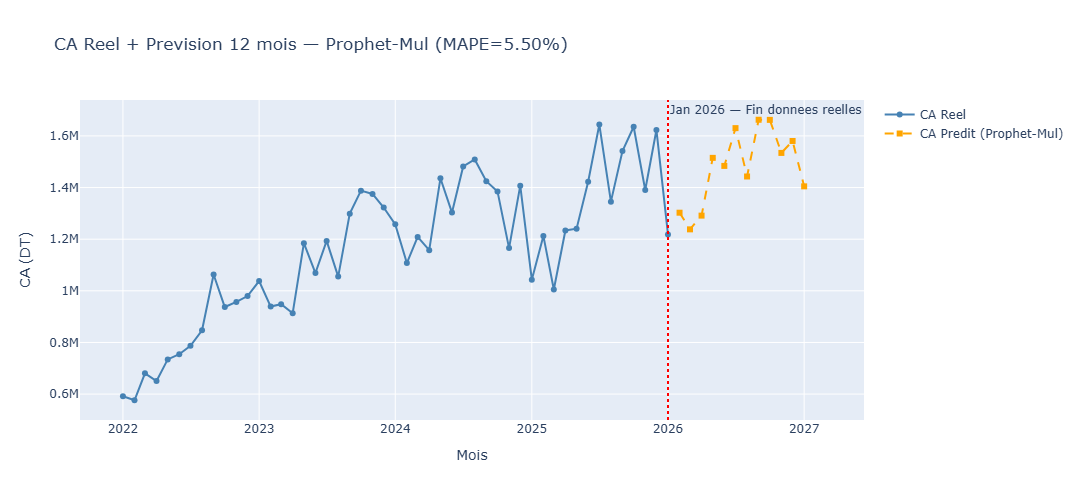

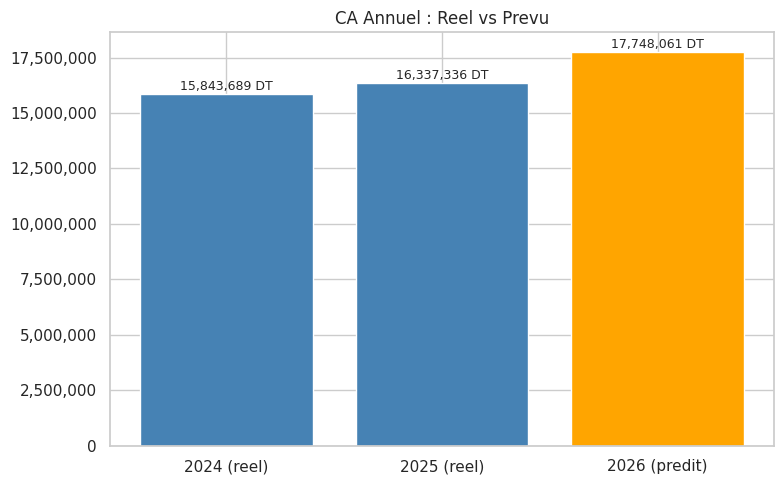

In [64]:
# ── Graphe Plotly final ────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ts.index, y=ts.values, name='CA Reel',
    mode='lines+markers', line=dict(color='steelblue', width=2)
))
fig.add_trace(go.Scatter(
    x=df_pred['date'], y=df_pred['predicted_sales'],
    name=f'CA Predit ({best_ts_name})',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))
fig.add_vline(
    x=ts.index[-1].timestamp()*1000,
    line_dash='dot', line_color='red',
    annotation_text=f'{ts.index[-1].strftime("%b %Y")} — Fin donnees reelles'
)
fig.update_layout(
    title=f'CA Reel + Prevision 12 mois — {best_ts_name} (MAPE={best_mape:.2f}%)',
    xaxis_title='Mois', yaxis_title='CA (DT)',
    hovermode='x unified', height=500
)
fig.show()

# CA annuel
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.bar(['2024 (reel)', '2025 (reel)', '2026 (predit)'],
        [ca_2024, ca_2025, ca_prev],
        color=['steelblue', 'steelblue', 'orange'])
for i, v in enumerate([ca_2024, ca_2025, ca_prev]):
    ax2.text(i, v + max(ca_2024,ca_2025,ca_prev)*0.01,
             f'{v:,.0f} DT', ha='center', fontsize=9)
ax2.set_title('CA Annuel : Reel vs Prevu')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [65]:
# ── Sauvegarde ClickHouse ──────────────────────────────────────
client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123', database='gold'
)
client2.command('DROP TABLE IF EXISTS gold.ml_predictions')
client2.command("""
    CREATE TABLE gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    ) ENGINE = MergeTree()
    ORDER BY date
""")
df_insert = df_pred[['date','year','month','predicted_sales','is_prediction']].copy()
df_insert['date'] = pd.to_datetime(df_insert['date']).dt.date
client2.insert_df('gold.ml_predictions', df_insert)
check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'{len(check)} predictions ecrites dans gold.ml_predictions')
print(check.to_string(index=False))

12 predictions ecrites dans gold.ml_predictions
      date  year  month  predicted_sales  is_prediction
2026-02-01  2026      2     1,302,552.67              1
2026-03-01  2026      3     1,238,119.97              1
2026-04-01  2026      4     1,291,302.00              1
2026-05-01  2026      5     1,514,993.18              1
2026-06-01  2026      6     1,483,841.60              1
2026-07-01  2026      7     1,630,253.67              1
2026-08-01  2026      8     1,442,859.69              1
2026-09-01  2026      9     1,662,661.64              1
2026-10-01  2026     10     1,662,180.06              1
2026-11-01  2026     11     1,534,156.84              1
2026-12-01  2026     12     1,580,445.52              1
2027-01-01  2027      1     1,404,694.20              1
